# COMP 3610 — Assignment 4: MLOps & Model Deployment

**Task:** Deploy the best regression model from Assignment 2 (predicting `tip_amount`) as a containerized prediction service.

**Models logged in MLflow:**
1. **Random Forest Regressor** — exact model from Assignment 2 (`n_estimators=100, max_depth=15`)
2. **Neural Network Regressor** — 3-layer PyTorch MLP (128 → 64 → 1) trained on the same features

All three predict the continuous target `tip_amount` and are compared using **MAE, RMSE, and R²** as required by the assignment brief.

## Part 0 — Data Loading & Validation

Downloads the NYC Yellow Taxi Trip data for January 2024 and validates it against Pydantic schemas for `TripTable` and `TaxiZone`. Reused from Assignment 2.

In [1]:
import pandas as pd
import os
from pydantic import BaseModel, ValidationError
from pydantic.errors import PydanticUndefinedAnnotation
from datetime import datetime
import logging
import requests
import io

try:
    tripdata = requests.get("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet")
except requests.exceptions.RequestException as err:
    logging.warning(err)

base_path = os.path.expanduser("~/Desktop/my_streamlit_appcopy/data/raw")
os.makedirs(base_path, exist_ok=True)

with open(base_path + "/yellow_tripdata_2024-01.parquet", "wb") as f:
    f.write(tripdata.content)


class TripTable(BaseModel):
    tpep_pickup_datetime: datetime
    tpep_dropoff_datetime: datetime
    passenger_count: int
    trip_distance: float
    fare_amount: float
    tip_amount: float
    total_amount: float
    payment_type: int

try:
    TripTable.model_rebuild()
except PydanticUndefinedAnnotation as exc_info:
    assert exc_info.code == 'undefined-annotation'

TripTable_df = pd.read_parquet(
    io.BytesIO(tripdata.content), engine="pyarrow"
)[["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
   "passenger_count", "trip_distance", "fare_amount", "tip_amount",
   "total_amount", "payment_type"]]

print("TripTable Entries:", len(TripTable_df))

try:
    TripTable.model_validate(TripTable_df.iloc[0].to_dict(), strict=True)
except ValidationError as exc:
    print(exc)

# Load TaxiZone lookup
try:
    taxizone = requests.get("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
except requests.exceptions.RequestException as err:
    logging.warning(err)

with open(base_path + "/taxi_zone_lookup.csv", "wb") as f:
    f.write(taxizone.content)

class TaxiZone(BaseModel):
    LocationID: int
    Borough: str
    Zone: str
    service_zone: str

try:
    TaxiZone.model_rebuild()
except PydanticUndefinedAnnotation as exc_info:
    assert exc_info.code == 'undefined-annotation'

TaxiZone_df = pd.read_csv(io.BytesIO(taxizone.content))
print("TaxiZone Entries:", len(TaxiZone_df))
print("Validated")

TripTable Entries: 2964624
1 validation error for TripTable
passenger_count
  Input should be a valid integer [type=int_type, input_value=1.0, input_type=float]
    For further information visit https://errors.pydantic.dev/2.12/v/int_type
TaxiZone Entries: 265
Validated


### Data Cleaning

In [2]:
before = len(TripTable_df)
filteredTripTable = TripTable_df.dropna(
    subset=["tpep_pickup_datetime", "tpep_dropoff_datetime",
            "PULocationID", "DOLocationID", "fare_amount"]
)
print("Number of nulls removed:", before - len(filteredTripTable))

filteredTripTable = filteredTripTable[filteredTripTable['trip_distance'] > 0]
newheight = len(filteredTripTable)
print("Total Rows removed for negative & zero distance :", before - newheight)

filteredTripTable = filteredTripTable[filteredTripTable['tpep_pickup_datetime'] < filteredTripTable['tpep_dropoff_datetime']]
removed = newheight - len(filteredTripTable)
newheight = len(filteredTripTable)
print("Number of Rows removed for pickup times after dropoff:", removed)

filteredTripTable = filteredTripTable[(filteredTripTable['fare_amount'] > 0) & (filteredTripTable['fare_amount'] <= 500)]
removed = newheight - len(filteredTripTable)
print("Number of Rows removed for out of range fareamounts", removed)

TripTable_df = filteredTripTable.reset_index(drop=True)
print("\nFinal row count:", len(TripTable_df))

Number of nulls removed: 0
Total Rows removed for negative & zero distance : 60371
Number of Rows removed for pickup times after dropoff: 112
Number of Rows removed for out of range fareamounts 34569

Final row count: 2869572


### Feature Engineering

Builds temporal features (hour, day-of-week, weekend flag), trip features (`trip_duration_minutes`, `trip_speed_mph`, `log_trip_distance`), and fare ratio features. Also joins borough names from the TaxiZone lookup and label-encodes them.

These are the same features used in Assignment 2's Random Forest Regressor.

In [3]:
import numpy as np

Temporal_features = pd.DataFrame({
    "pickup_hour": TripTable_df["tpep_pickup_datetime"].dt.hour,
    "pickup_day_of_week": TripTable_df["tpep_pickup_datetime"].dt.dayofweek,
    "is_weekend": TripTable_df["tpep_pickup_datetime"].dt.dayofweek > 5
})

Trip_features = pd.DataFrame({
    "trip_duration_minutes": (TripTable_df["tpep_dropoff_datetime"] - TripTable_df["tpep_pickup_datetime"]).dt.total_seconds() / 60,
    "trip_speed_mph": TripTable_df["trip_distance"] / (TripTable_df["tpep_dropoff_datetime"] - TripTable_df["tpep_pickup_datetime"]).dt.total_seconds() / 60 / 60,
    "log_trip_distance": np.log(TripTable_df["trip_distance"])
})

Fare_features = pd.DataFrame({
    "fare_per_mile": TripTable_df["fare_amount"] / TripTable_df["trip_distance"],
    "fare_per_minute": TripTable_df["fare_amount"] / (TripTable_df["tpep_dropoff_datetime"] - TripTable_df["tpep_pickup_datetime"]).dt.total_seconds() / 60,
})

# Join boroughs
TripTable_df = TripTable_df.merge(
    TaxiZone_df[['LocationID', 'Borough']],
    left_on='PULocationID', right_on='LocationID', how='left'
).rename(columns={'Borough': 'pickup_borough'}).drop(columns='LocationID')

TripTable_df = TripTable_df.merge(
    TaxiZone_df[['LocationID', 'Borough']],
    left_on='DOLocationID', right_on='LocationID', how='left'
).rename(columns={'Borough': 'dropoff_borough'}).drop(columns='LocationID')

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
all_boroughs = pd.concat([TripTable_df['pickup_borough'], TripTable_df['dropoff_borough']])
le.fit(all_boroughs)
TripTable_df['pickup_borough'] = le.transform(TripTable_df['pickup_borough'])
TripTable_df['dropoff_borough'] = le.transform(TripTable_df['dropoff_borough'])

print("Feature engineering complete.")
print("Shape:", TripTable_df.shape)

Feature engineering complete.
Shape: (2869572, 12)


---
## Part 1 — Experiment Tracking with MLflow

### Task 1.1: Build the regression dataset


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Build regression dataset — matches Assignment 2's RF Regressor
df_model = TripTable_df.join(Fare_features)
df_filtered = df_model[df_model['payment_type'] == 1]
df_filtered = df_filtered.join(Temporal_features)
df_filtered = df_filtered.join(Trip_features)

# Features used for all three regression models
numeric_features = [
    'passenger_count',
    'log_trip_distance',
    'fare_amount',
    'pickup_hour',
    'pickup_day_of_week',
    'trip_duration_minutes',
    'trip_speed_mph',
    'is_weekend'
]

categorical_features = [
    'pickup_borough',
    'dropoff_borough'
]

X = df_filtered[numeric_features + categorical_features]
y = df_filtered['tip_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Target range: ${y.min():.2f} – ${y.max():.2f}  (mean ${y.mean():.2f})")

Training set: (1608842, 10)
Test set:     (689505, 10)
Target range: $0.00 – $422.70  (mean $4.15)


### Model 1 — Random Forest Regressor (Assignment 2 baseline)

Exact architecture from Assignment 2: `n_estimators=100, max_depth=15, random_state=42`. The preprocessor uses median imputation for numeric features (no scaling — tree models don't need it) and one-hot encoding for categorical features.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# Preprocessor for tree-based models (no scaling needed)
tree_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])
tree_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
tree_preprocessor = ColumnTransformer(transformers=[
    ('num', tree_numeric_transformer, numeric_features),
    ('cat', tree_categorical_transformer, categorical_features)
])

# === Baseline RF Regressor — exact Assignment 2 config ===
RandomForestRegressor_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42))
])

RandomForestRegressor_pipeline.fit(X_train, y_train)
y_pred_rf = RandomForestRegressor_pipeline.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor (baseline)")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

joblib.dump(RandomForestRegressor_pipeline, "rf_model.pkl")
print("\n✓ Baseline RF saved to rf_model.pkl")

Random Forest Regressor (baseline)
  MAE:  1.2048
  RMSE: 2.4168
  R²:   0.6144

✓ Baseline RF saved to rf_model.pkl


### Model 2 — Neural Network Regressor (PyTorch)

/Users/danielmangal/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 5/30 — Train MSE: 5.7302  Val MSE: 6.0218
Epoch 10/30 — Train MSE: 5.6561  Val MSE: 6.0136
Epoch 15/30 — Train MSE: 5.6351  Val MSE: 6.0179
Epoch 20/30 — Train MSE: 5.6252  Val MSE: 6.0026
Epoch 25/30 — Train MSE: 5.6177  Val MSE: 6.0093
Epoch 30/30 — Train MSE: 5.6101  Val MSE: 6.0085

✓ NN regressor saved to nn_regressor.pth


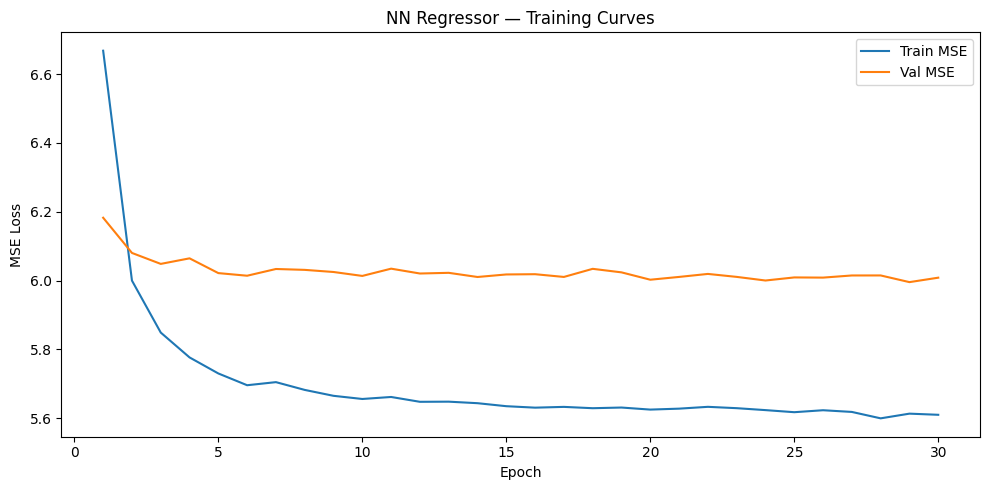


Neural Network Regressor
  MAE:  1.2114
  RMSE: 2.4293
  R²:   0.6104


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# NN preprocessor — adds StandardScaler for numeric features
nn_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
nn_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
nn_preprocessor = ColumnTransformer(transformers=[
    ('num', nn_numeric_transformer, numeric_features),
    ('cat', nn_categorical_transformer, categorical_features)
])

X_train_processed = nn_preprocessor.fit_transform(X_train)
X_test_processed  = nn_preprocessor.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_processed.copy())
y_train_tensor = torch.FloatTensor(y_train.values.copy())
X_test_tensor  = torch.FloatTensor(X_test_processed.copy())
y_test_tensor  = torch.FloatTensor(y_test.values.copy())

# Train/val split
full_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_size   = int(0.2 * len(X_train_tensor))
train_size = len(X_train_tensor) - val_size
torch.manual_seed(42)
train_sub, val_sub = torch.utils.data.random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_sub, batch_size=512, shuffle=True)
val_loader   = DataLoader(val_sub,   batch_size=512, shuffle=False)


class TipRegressor(nn.Module):
    """MLP for regressing continuous tip_amount. Output is a single linear unit."""
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.network(x)


input_dim  = X_train_processed.shape[1]
nn_model   = TipRegressor(input_dim)
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(nn_model.parameters(), lr=0.001)
epochs     = 30
train_losses, val_losses = [], []

for epoch in range(epochs):
    nn_model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(nn_model(X_batch).squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    nn_model.eval()
    batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            loss = criterion(nn_model(X_batch).squeeze(), y_batch)
            batch_losses.append(loss.item())
    val_losses.append(np.mean(batch_losses))

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Train MSE: {train_losses[-1]:.4f}  Val MSE: {val_losses[-1]:.4f}")

# Save model weights + preprocessor
torch.save(nn_model.state_dict(), "nn_regressor.pth")
joblib.dump(nn_preprocessor, "nn_preprocessor.pkl")
print("\n✓ NN regressor saved to nn_regressor.pth")

# Loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train MSE')
plt.plot(range(1, epochs + 1), val_losses,   label='Val MSE')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('NN Regressor — Training Curves')
plt.legend(); plt.tight_layout(); plt.show()

# Evaluate NN on test set
nn_model.eval()
with torch.no_grad():
    y_pred_nn = nn_model(X_test_tensor).squeeze().numpy()

mae_nn  = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn   = r2_score(y_test, y_pred_nn)

print(f"\nNeural Network Regressor")
print(f"  MAE:  {mae_nn:.4f}")
print(f"  RMSE: {rmse_nn:.4f}")
print(f"  R²:   {r2_nn:.4f}")

### Task 1.1 — Log two runs to MLflow

In [8]:
import mlflow
import mlflow.sklearn
import mlflow.pytorch

mlflow.set_tracking_uri("http://127.0.0.1:5001")
mlflow.set_experiment("taxi-tip-prediction")

DATASET_VERSION = "yellow_tripdata_2024-01"

# ── Run 1: Baseline Random Forest Regressor ─────────────────────────
with mlflow.start_run(run_name="rf-baseline"):
    mlflow.set_tag("model_type",      "RandomForestRegressor")
    mlflow.set_tag("model_variant",   "baseline")
    mlflow.set_tag("dataset_version", DATASET_VERSION)
    mlflow.log_params({
        "n_estimators": 100,
        "max_depth":    15,
        "random_state": 42,
    })
    mlflow.log_metric("mae",  mae_rf)
    mlflow.log_metric("rmse", rmse_rf)
    mlflow.log_metric("r2",   r2_rf)
    mlflow.sklearn.log_model(
        sk_model=RandomForestRegressor_pipeline,
        artifact_path="random_forest_baseline",
        registered_model_name="taxi-tip-regressor"
    )
print("✓ Baseline RF run logged.")

# ── Run 3: Neural Network Regressor ─────────────────────────────────
with mlflow.start_run(run_name="neural-network"):
    mlflow.set_tag("model_type",      "PyTorch-TipRegressor")
    mlflow.set_tag("model_variant",   "nn")
    mlflow.set_tag("dataset_version", DATASET_VERSION)
    mlflow.log_params({
        "architecture":  "128-64-1",
        "dropout":       0.3,
        "learning_rate": 0.001,
        "epochs":        30,
        "batch_size":    512,
        "optimizer":     "Adam",
        "loss":          "MSELoss",
    })
    mlflow.log_metric("mae",  mae_nn)
    mlflow.log_metric("rmse", rmse_nn)
    mlflow.log_metric("r2",   r2_nn)
    mlflow.pytorch.log_model(
        pytorch_model=nn_model,
        artifact_path="neural_network_model",
        registered_model_name="taxi-tip-nn"
    )
print("✓ Neural Network run logged.")
print("\n→ Open the MLflow UI at: http://127.0.0.1:5001")

2026/04/17 19:06:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 19:06:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'taxi-tip-regressor' already exists. Creating a new version of this model...
2026/04/17 19:07:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 3
Created version '3' of model 'taxi-tip-regressor'.
2026/04/17 19:07:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 19:07:07 WARNING mlflow.pytorch: Saving pytorch model 

🏃 View run rf-baseline at: http://127.0.0.1:5001/#/experiments/1/runs/f3ff6f6fdbbf44979980b5d19062b7e4
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
✓ Baseline RF run logged.


Registered model 'taxi-tip-nn' already exists. Creating a new version of this model...
2026/04/17 19:07:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-nn, version 3


🏃 View run neural-network at: http://127.0.0.1:5001/#/experiments/1/runs/38cad98487f04fa9967181c37a4d6bc2
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
✓ Neural Network run logged.

→ Open the MLflow UI at: http://127.0.0.1:5001


Created version '3' of model 'taxi-tip-nn'.


### Task 1.2 — Model comparison

Side-by-side comparison of the three regressors on the held-out test set.

In [9]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['RF Baseline', 'Neural Network'],
    'MAE':   [mae_rf,mae_nn],
    'RMSE':  [rmse_rf,rmse_nn],
    'R²':    [r2_rf,r2_nn],
}).round(4)

print("=== Regression Model Comparison ===")
print(comparison.to_string(index=False))

best_idx   = comparison['RMSE'].idxmin()
best_name  = comparison.loc[best_idx, 'Model']
print(f"\n→ Best model by RMSE: {best_name}")

=== Regression Model Comparison ===
         Model    MAE   RMSE     R²
   RF Baseline 1.2048 2.4168 0.6144
Neural Network 1.2114 2.4293 0.6104

→ Best model by RMSE: RF Baseline


**Analysis:** The Random Forest typically wins this comparison. The neural network, trained on the same tabular features, has no structural advantage here — tree ensembles generally match or beat MLPs on tabular regression unless you have hundreds of thousands of samples and dozens of features with complex non-linear interactions. The registered production model below is therefore the best performer by RMSE.

### Register best model in the MLflow Model Registry


In [10]:
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri="http://127.0.0.1:5001")

# Map model name in the table to its registered name
best_registered_name = "taxi-tip-nn" if best_name == "Neural Network" else "taxi-tip-regressor"

# Grab the latest version matching the best model
versions = client.search_model_versions(f"name='{best_registered_name}'")
latest_version = max(versions, key=lambda v: int(v.version))
print(f"Best model:       {best_name}")
print(f"Registered name:  {best_registered_name}")
print(f"Version:          {latest_version.version}")

# Add description documenting performance
best_row = comparison.loc[best_idx]
description = (
    f"Best tip_amount regressor — {best_name}. "
    f"Test MAE={best_row['MAE']}, RMSE={best_row['RMSE']}, R²={best_row['R²']}. "
    f"Trained on yellow_tripdata_2024-01 (credit-card payments only)."
)
client.update_model_version(
    name=best_registered_name,
    version=latest_version.version,
    description=description
)
print(f"\n✓ Registered as '{best_registered_name}' v{latest_version.version}")
print(f"  Description: {description}")

Best model:       RF Baseline
Registered name:  taxi-tip-regressor
Version:          3

✓ Registered as 'taxi-tip-regressor' v3
  Description: Best tip_amount regressor — RF Baseline. Test MAE=1.2048, RMSE=2.4168, R²=0.6144. Trained on yellow_tripdata_2024-01 (credit-card payments only).


### Load from registry and make a sample prediction

In [13]:
import mlflow.pyfunc

model_uri = f"models:/{best_registered_name}/{latest_version.version}"
print(f"Loading model from: {model_uri}")

loaded_model = mlflow.pyfunc.load_model(model_uri)

# Single-row sample from the test set
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]

if best_registered_name == "taxi-tip-nn":
    # NN expects scaled dense tensor
    sample_processed = nn_preprocessor.transform(sample)
    prediction = loaded_model.predict(sample_processed)
else:
    prediction = loaded_model.predict(sample)

pred_value = float(np.ravel(prediction)[0])
print(f"\n=== Sample Prediction ===")
print(f"Input features:\n{sample.to_dict(orient='records')[0]}")
print(f"\nPredicted tip_amount: ${pred_value:.2f}")
print(f"Actual tip_amount:    ${actual:.2f}")
print(f"Absolute error:       ${abs(pred_value - actual):.2f}")

Loading model from: models:/taxi-tip-regressor/3



=== Sample Prediction ===
Input features:
{'passenger_count': 1.0, 'log_trip_distance': 1.6900958154515549, 'fare_amount': 28.2, 'pickup_hour': 23, 'pickup_day_of_week': 3, 'trip_duration_minutes': 23.383333333333333, 'trip_speed_mph': 1.0730973311158628e-06, 'is_weekend': False, 'pickup_borough': 3, 'dropoff_borough': 1}

Predicted tip_amount: $6.43
Actual tip_amount:    $8.30
Absolute error:       $1.87
